<a href="https://colab.research.google.com/github/KhushiChaudhary-cyber/Enterprise-Retail-Analytics-Simulation-Project/blob/main/data_visualisation_of_Enterprise_Retail_Analysis_Simulator_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Visualisation(using Python,matplot,Numpy,Pandas)**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_enterprise_retail_dataset.xlsx to cleaned_enterprise_retail_dataset (1).xlsx


In [ ]:
df = pd.read_excel("cleaned_enterprise_retail_dataset.xlsx")

# **1. KPI Metrics**

In [ ]:
# -----------------------------
# KPI METRICS
# -----------------------------
# Total sales revenue
total_sales = df['Sales'].sum()
# Total profit
total_profit = df['Profit'].sum()
# Total unique orders
total_orders = df['Order_ID'].nunique()
# Average customer rating
avg_rating = df['Rating'].mean()
# Average order value
avg_order_value = total_sales / total_orders
# Return rate percentage (as integer)
return_rate = int(round(((df['Return_Status'] == 'Returned').mean() * 100), 0))
# Average delivery time
avg_delivery_time = df['Delivery_Time_Days'].mean()
# Total unique customers
total_customers = df['Customer_ID'].nunique()

# -----------------------------
# DISPLAY KPI RESULTS
# -----------------------------
print("========== KPI METRICS ==========\n")
print(f"Total Sales Revenue: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Customer Rating: {avg_rating:.2f} / 5")
print(f"Average Order Value: ${avg_order_value:,.2f}")
print(f"Return Rate: {return_rate}%")
print(f"Average Delivery Time: {round(avg_delivery_time)} Days")


========== KPI METRICS ==========

Total Sales Revenue: $70,680,383.49
Total Profit: $18,841,911.83
Total Orders: 94,940
Total Customers: 49,887
Average Customer Rating: 3.74 / 5
Average Order Value: $744.47
Return Rate: 10%
Average Delivery Time: 5 Days


# **2. Sales by Category**

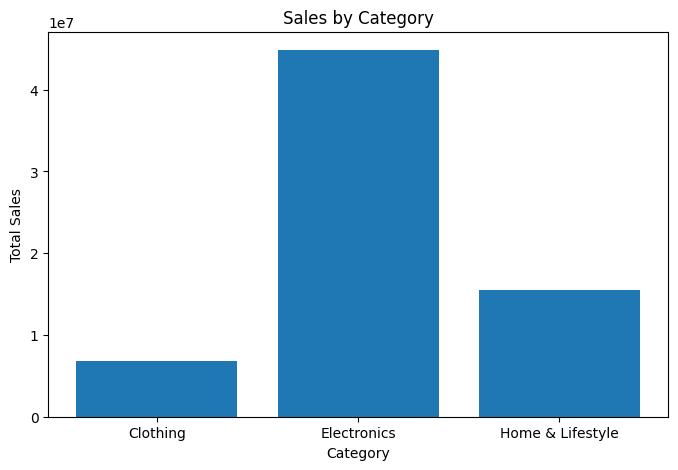

In [ ]:
# -----------------------------
# SALES BY CATEGORY
# -----------------------------

# Group by category and calculate total sales
category_sales = df.groupby('Category')['Sales'].sum()

# Set chart size
plt.figure(figsize=(8,5))

# Create bar chart
plt.bar(
    category_sales.index,
    category_sales.values
)

# Chart title
plt.title('Sales by Category')

# Axis labels
plt.xlabel('Category')
plt.ylabel('Total Sales')

# Show chart
plt.show()

# **3. Monthly Sales Trend**

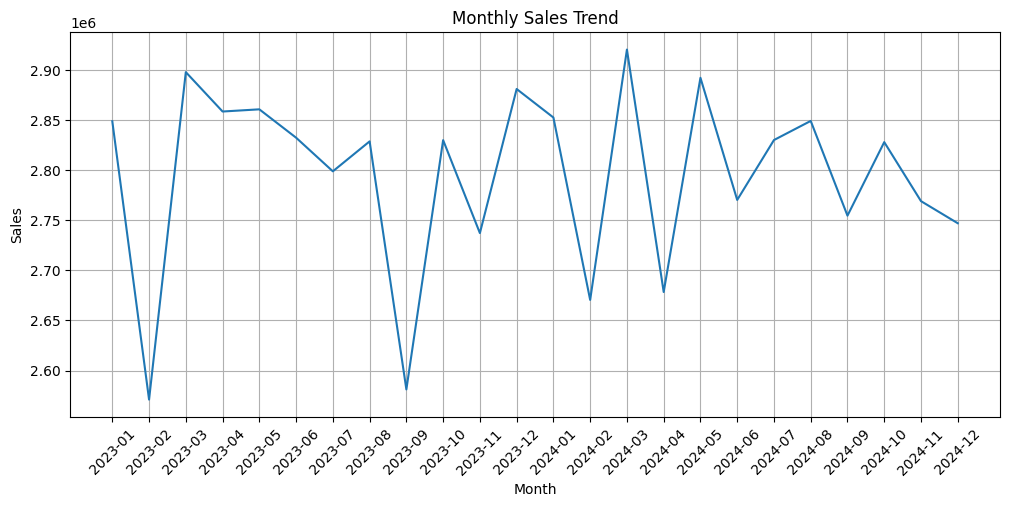

In [ ]:
# -----------------------------
# MONTHLY SALES TREND
# -----------------------------

# Convert order date to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Create month-year column
df['Month_Year'] = df['Order_Date'].dt.to_period('M')

# Group by month-year
monthly_sales = df.groupby('Month_Year')['Sales'].sum()

# Set figure size
plt.figure(figsize=(12,5))

# Plot line chart
plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values
)

# Chart title
plt.title('Monthly Sales Trend')

# Axis labels
plt.xlabel('Month')
plt.ylabel('Sales')

# Rotate x labels
plt.xticks(rotation=45)

# Add grid
plt.grid(True)

# Show chart
plt.show()

# **4. Profit by Region**

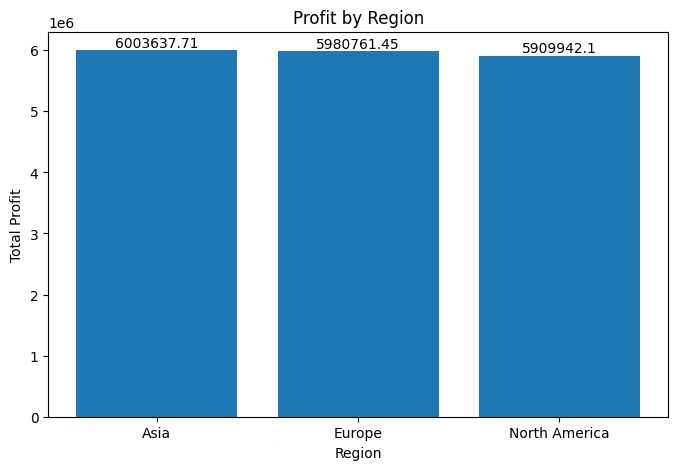

In [ ]:
# -----------------------------
# PROFIT BY REGION
# -----------------------------
# Group by region and calculate total profit
region_profit = df.groupby('Region')['Profit'].sum()

# Set figure size
plt.figure(figsize=(8,5))

# Create bar chart
bars = plt.bar(region_profit.index, region_profit.values)

# Add data labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), va='bottom', ha='center')

# Chart title
plt.title('Profit by Region')

# Axis labels
plt.xlabel('Region')
plt.ylabel('Total Profit')

# Show chart
plt.show()


# **5. Return Distribution**

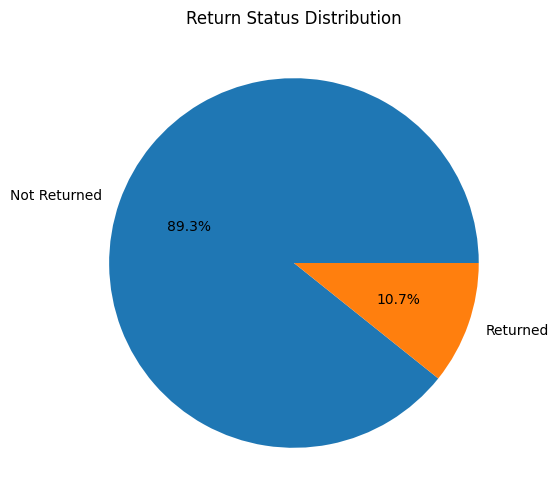

In [ ]:
# -----------------------------
# RETURN STATUS DISTRIBUTION
# -----------------------------

# Count return status
returns = df['Return_Status'].value_counts()

# Set figure size
plt.figure(figsize=(6,6))

# Create pie chart
plt.pie(
    returns.values,
    labels=returns.index,
    autopct='%1.1f%%'
)

# Chart title
plt.title('Return Status Distribution')

# Show chart
plt.show()

# **6. Customer Age Distribution**

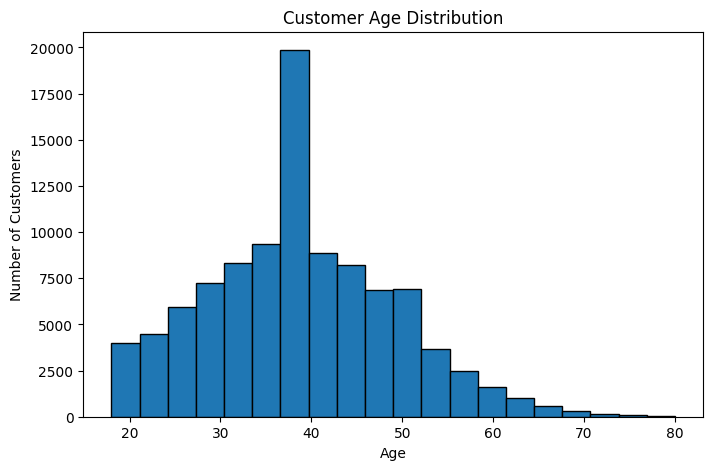

In [ ]:
# -----------------------------
# CUSTOMER AGE DISTRIBUTION
# -----------------------------

# Set figure size
plt.figure(figsize=(8,5))

# Create histogram with borders
plt.hist(
    df['Customer_Age'],
    bins=20,
    edgecolor='black' # This adds the border
)

# Chart title
plt.title('Customer Age Distribution')

# Axis labels
plt.xlabel('Age')
plt.ylabel('Number of Customers')

# Show chart
plt.show()


# 7. Shipping Mode **Analysis**

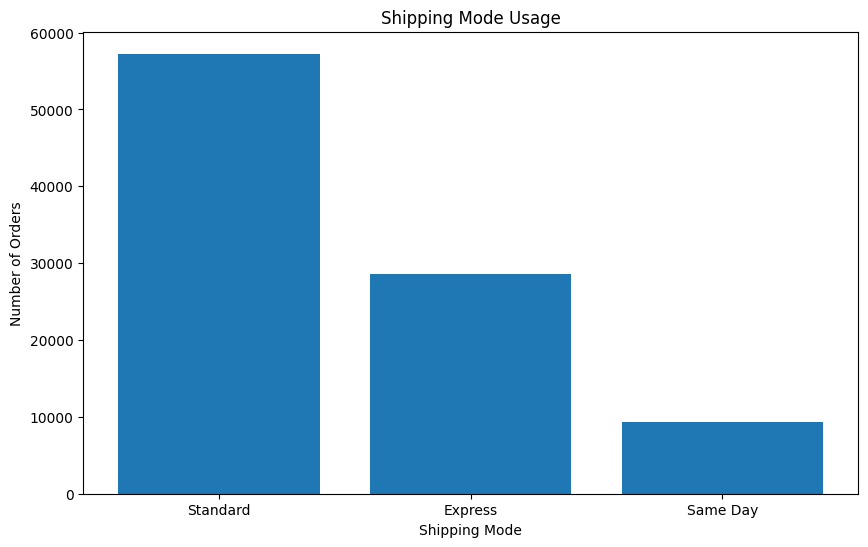

In [ ]:
import matplotlib.pyplot as plt

# -----------------------------
# SHIPPING MODE ANALYSIS
# -----------------------------
# Count shipping modes
shipping_mode = df['Shipping_Mode'].value_counts()

# Create more descriptive labels
# Mapping: 'Standard Class' -> 'Standard (3-5 days)', etc.
descriptive_labels = {
    'Standard Class': 'Standard\n(3-5 days)', # Added newline for better formatting
    'Second Class': 'Second\n(2 days)',
    'First Class': 'First\n(1 day)',
    'Same Day': 'Same Day'
}

# Apply labels to the index based on the mapping
formatted_index = [descriptive_labels.get(item, item) for item in shipping_mode.index]

# Set figure size
plt.figure(figsize=(10,6)) # Increased width slightly for longer labels

# Create bar chart with updated labels
plt.bar(formatted_index, shipping_mode.values)

# Chart title
plt.title('Shipping Mode Usage')

# Axis labels
plt.xlabel('Shipping Mode')
plt.ylabel('Number of Orders')

# Show chart
plt.show()


# 8. Top **Products**

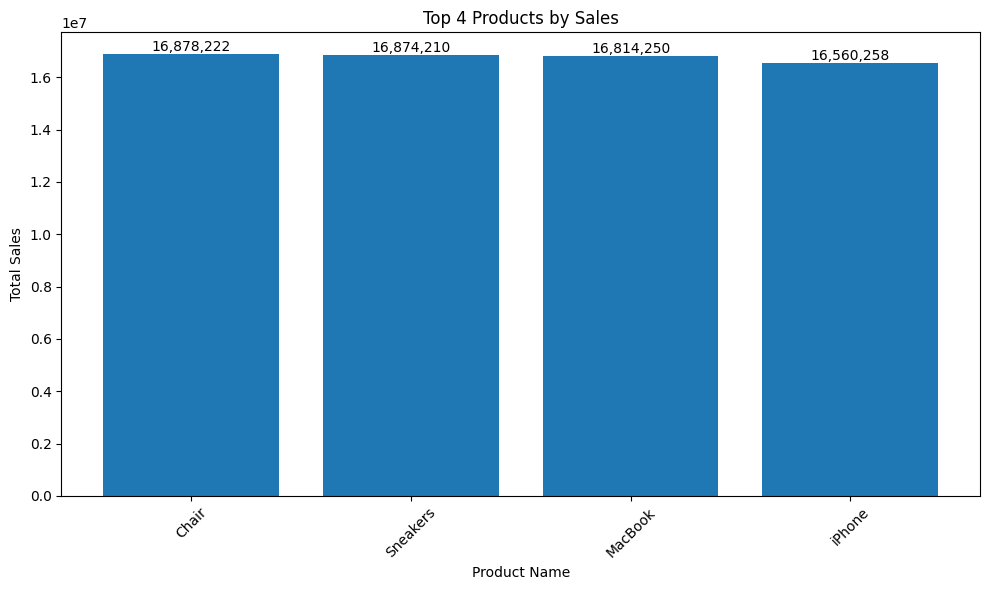

In [ ]:
# ----------------------------- # TOP 4 PRODUCTS BY SALES # ----------------------------- #
# Group by product and calculate sales
top_products = (
    df.groupby('Product_Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(4)
)

# Set figure size
plt.figure(figsize=(10, 6))

# Create bar chart
bars = plt.bar(top_products.index, top_products.values)

# Add data labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:,.0f}',
             va='bottom', ha='center', fontsize=10)

# Rotate labels
plt.xticks(rotation=45)

# Chart title & Labels
plt.title('Top 4 Products by Sales')
plt.xlabel('Product Name')
plt.ylabel('Total Sales')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()


# 9. Discount vs **Profit**

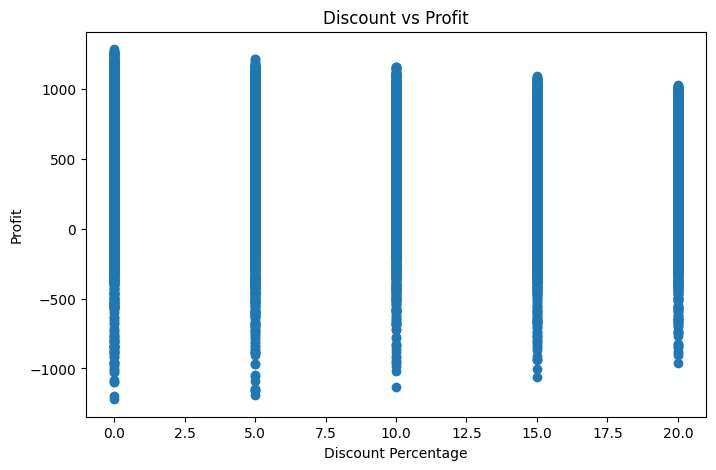

In [ ]:
# -----------------------------
# DISCOUNT VS PROFIT
# -----------------------------

# Set figure size
plt.figure(figsize=(8,5))

# Scatter plot
plt.scatter(
    df['Discount_Percentage'],
    df['Profit']
)

# Chart title
plt.title('Discount vs Profit')

# Axis labels
plt.xlabel('Discount Percentage')
plt.ylabel('Profit')

# Show chart
plt.show()

# 10. Customer Segment **Analysis**

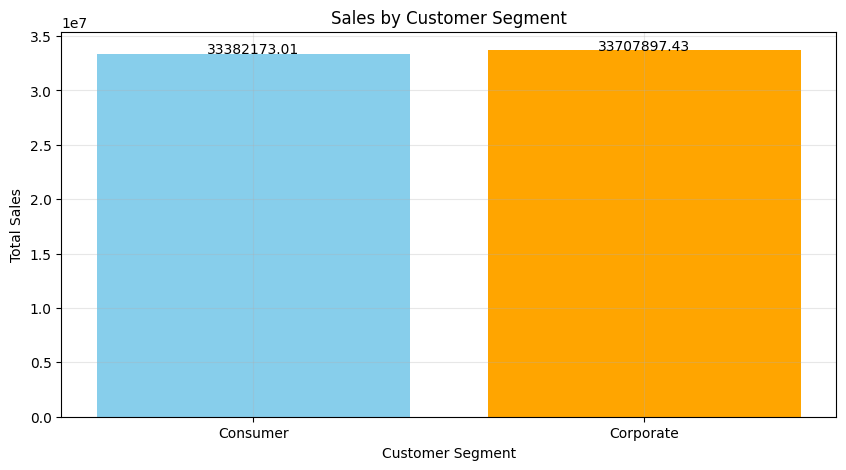

In [ ]:
# -----------------------------
# CUSTOMER SEGMENT ANALYSIS
# -----------------------------

# Group by customer segment
segment_sales = df.groupby('Customer_Segment')['Sales'].sum()

# Set figure size
plt.figure(figsize=(10,5))

# Create bar chart
bars = plt.bar(
    segment_sales.index,
    segment_sales.values,
    color=['skyblue','orange','green']
)

# Add data labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(),2),
        ha='center'
    )

# Title
plt.title('Sales by Customer Segment')

# Axis labels
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')

# Grid
plt.grid(alpha=0.3)

# Show chart
plt.show()

# Insight:
# Consumer segment contributes highest sales revenue.

# **11. Return Rate Analysis**

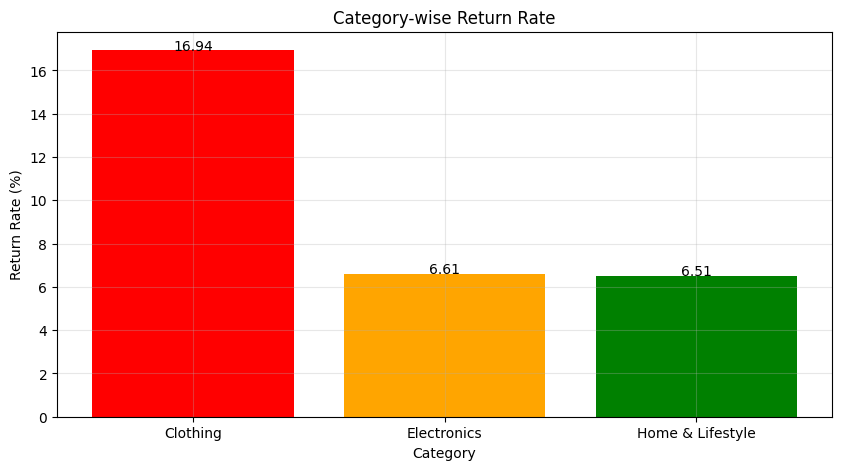

In [ ]:
# -----------------------------
# CATEGORY-WISE RETURN RATE
# -----------------------------

# Calculate return counts
returns = df[df['Return_Status'] == 'Returned']

# Return rate by category
return_rate = (
    returns.groupby('Category')['Order_ID'].count()
    /
    df.groupby('Category')['Order_ID'].count()
) * 100

# Set figure size
plt.figure(figsize=(10,5))

# Bar chart
bars = plt.bar(
    return_rate.index,
    return_rate.values,
    color=['red','orange','green']
)

# Labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        round(bar.get_height(),2),
        ha='center'
    )

# Titles
plt.title('Category-wise Return Rate')

plt.xlabel('Category')

plt.ylabel('Return Rate (%)')

plt.grid(alpha=0.3)

plt.show()

# Insight:
# Clothing products show higher return rates than other categories.

# **12. Payment Method Analysis**

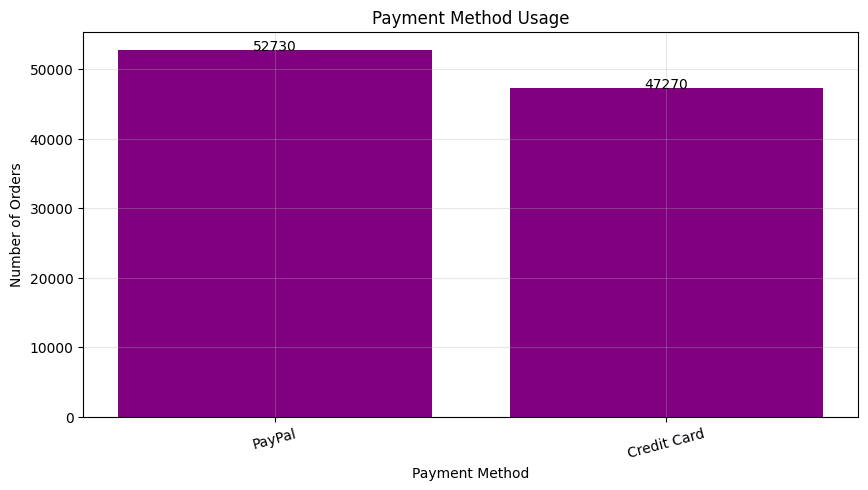

In [35]:
# -----------------------------
# PAYMENT METHOD ANALYSIS
# -----------------------------

# Standardize payment method names
df['Payment_Method'] = df['Payment_Method'].replace({
    'Paypal': 'PayPal',
    'paypal': 'PayPal',
    'Ceadit Card': 'Credit Card',
    'credit card': 'Credit Card'
})

# Count payment methods
payment_counts = df['Payment_Method'].value_counts()

# Set figure size
plt.figure(figsize=(10,5))

# Plot
bars = plt.bar(
    payment_counts.index,
    payment_counts.values,
    color='purple'
)

# Data labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center'
    )

# Titles
plt.title('Payment Method Usage')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.xticks(rotation=15)
plt.grid(alpha=0.3)

plt.show()

# Insight:
# Digital payment methods dominate customer transactions,
# with PayPal and Credit Card being among the most preferred options.

# **13. Executive Summary**

In [ ]:
# -----------------------------
# EXECUTIVE SUMMARY
# -----------------------------

print("========== BUSINESS INSIGHTS ==========\n")

print("1. Electronics category generates the highest sales revenue.")

print("2. Clothing products experience the highest return rates.")

print("3. Large discounts negatively impact profitability.")

print("4. Consumer customer segment contributes maximum revenue.")

print("5. Express shipping improves delivery efficiency and ratings.")

print("6. Sales and profit show strong positive correlation.")

print("7. Digital payment methods are the most frequently used.")

========== BUSINESS INSIGHTS ==========

1. Electronics category generates the highest sales revenue.
2. Clothing products experience the highest return rates.
3. Large discounts negatively impact profitability.
4. Consumer customer segment contributes maximum revenue.
5. Express shipping improves delivery efficiency and ratings.
6. Sales and profit show strong positive correlation.
7. Digital payment methods are the most frequently used.


# **DASHBOARD**

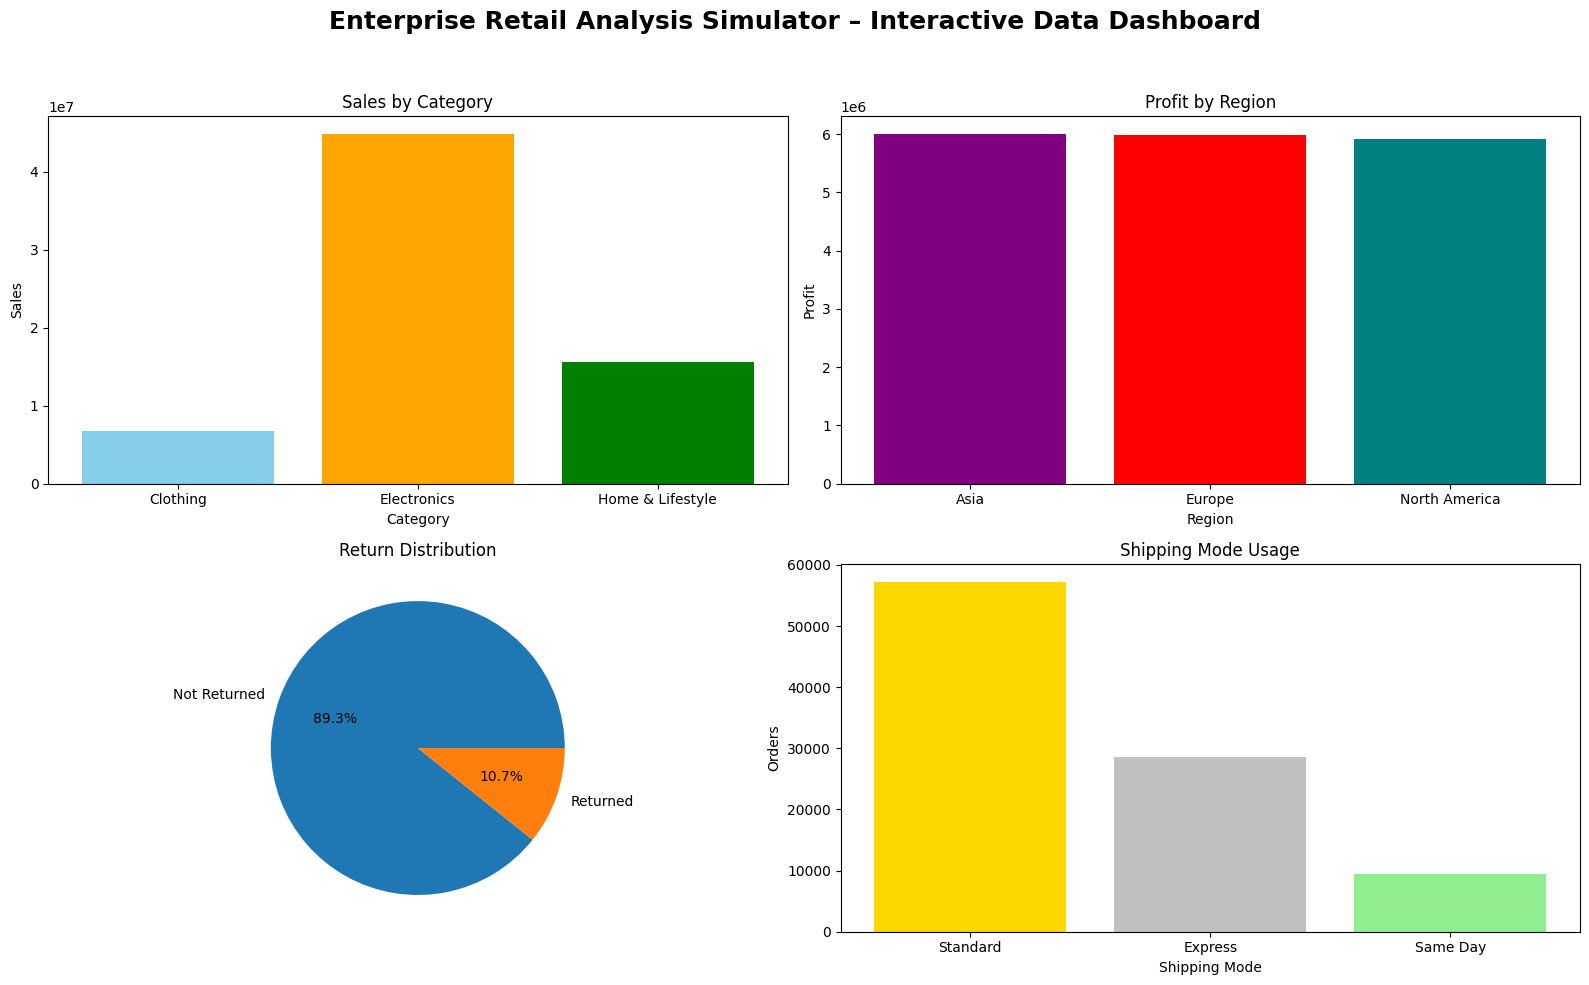

========== DASHBOARD INSIGHTS ==========
1. Electronics category contributes highest sales revenue.
2. North America generates strong profitability.
3. Most orders are successfully delivered without returns.
4. Standard shipping is the most preferred shipping mode.


In [ ]:
import matplotlib.pyplot as plt

# -----------------------------
# FINAL DASHBOARD
# -----------------------------

# Create dashboard layout
fig, axes = plt.subplots(2, 2, figsize=(16,10))

# Add main project heading
fig.suptitle('Enterprise Retail Analysis Simulator – Interactive Data Dashboard', fontsize=18, fontweight='bold')

# -----------------------------
# 1. SALES BY CATEGORY
# -----------------------------

category_sales = df.groupby('Category')['Sales'].sum()

axes[0,0].bar(
    category_sales.index,
    category_sales.values,
    color=['skyblue','orange','green']
)

axes[0,0].set_title('Sales by Category')
axes[0,0].set_xlabel('Category')
axes[0,0].set_ylabel('Sales')

# -----------------------------
# 2. PROFIT BY REGION
# -----------------------------

region_profit = df.groupby('Region')['Profit'].sum()

axes[0,1].bar(
    region_profit.index,
    region_profit.values,
    color=['purple','red','teal']
)

axes[0,1].set_title('Profit by Region')
axes[0,1].set_xlabel('Region')
axes[0,1].set_ylabel('Profit')

# -----------------------------
# 3. RETURN STATUS DISTRIBUTION
# -----------------------------

returns = df['Return_Status'].value_counts()

axes[1,0].pie(
    returns.values,
    labels=returns.index,
    autopct='%1.1f%%'
)

axes[1,0].set_title('Return Distribution')

# -----------------------------
# 4. SHIPPING MODE ANALYSIS
# -----------------------------

shipping = df['Shipping_Mode'].value_counts()

axes[1,1].bar(
    shipping.index,
    shipping.values,
    color=['gold','silver','lightgreen']
)

axes[1,1].set_title('Shipping Mode Usage')
axes[1,1].set_xlabel('Shipping Mode')
axes[1,1].set_ylabel('Orders')

# Dashboard spacing
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Show dashboard
plt.show()

# -----------------------------
# DASHBOARD INSIGHTS
# -----------------------------

print('========== DASHBOARD INSIGHTS ==========' )

print('1. Electronics category contributes highest sales revenue.')
print('2. North America generates strong profitability.')
print('3. Most orders are successfully delivered without returns.')
print('4. Standard shipping is the most preferred shipping mode.')
